# Excitonic torque on the classical moments

This notebook isolates the **first variation** of the exciton effective action — the
mean force that the exciton sector exerts on the two layer magnetizations. It reuses the
calibrated single-mode machinery of `Static_D` / `BrightExcitonMode` /
`ExcitonSpinSusceptibility`; nothing new is fit here.

## Where the torque sits

Integrating out the electrons (after a Hubbard–Stratonovich in the electron–hole
channel) gives the effective action for the classical moments,
$$
S_{\rm eff}[M]=S_{\rm spin}[M]+\mathrm{Tr}\ln D^{-1}[M],\qquad D=(V^{-1}-\Pi[M])^{-1}.
$$
The exciton–moment coupling enters only through $\Pi[M]$ via the spin overlap
$\cos(\theta/2)=\sqrt{(1+M_1\!\cdot\!M_2)/2}$ (interlayer tunneling).

The **torque is the first variation** — a single derivative in $M$, hence a **single $D$**:
$$
T_l^a=-\frac{\delta S_{\rm eff}}{\delta M_l^a}
=-\frac{\delta S_{\rm spin}}{\delta M_l^a}
+\underbrace{\mathrm{Tr}\!\big[D\,\Lambda_l^a\big]}_{\text{exciton}},
\qquad \Lambda_l^a=\frac{\partial\Pi}{\partial M_l^a}.
$$

Being a **mean value** (mean force), the torque is the **lesser** component in the trace,
$\mathrm{Tr}[D\Lambda]\to -i\,\mathrm{Tr}[D^<\Lambda]$: it is carried by the **occupation**, so it is
intrinsically $\propto N$ (population) and vanishes for an empty exciton. What is
**retarded** is only the *coefficient*: on the bright mode, Hellmann–Feynman gives
$Z\langle X|\Lambda|X\rangle=\partial E_X/\partial M$ (the pole shift). Because there is a **single $D$**
(no two-$D$ loop, no $R$–$<$ convolution), the lesser factorizes cleanly as a scalar $N$
times the retarded coefficient times a geometric cross product,
$$
T\;=\;\underbrace{N}_{D^<}\;\times\;\underbrace{\frac{\partial E_X}{\partial M}}_{\text{retarded (HF)}}\;\times\;(M_l\times M_{l'}).
$$

> Scope: here we compute the **per-exciton coefficient** ($N=1$) — the retarded
> $\partial E_X/\partial M$ and its cross-product geometry. The microscopic population $N$
> (screening $W$, excited $G$, $D^<\!\propto\!N$) is the next, model-improvement step.

In [2]:
using LinearAlgebra
using Printf
using PyPlot

rc("font", family="serif"); rc("font", size=13)
rc("axes", labelsize=14, titlesize=14); rc("legend", fontsize=10)

# -----------------------------
# Calibrated parameters (eV) — identical set to Static_D / ExcitonSpinSusceptibility:
# bright A exciton at 1.360 eV (AFM), 15 meV red-shift to FM.
# -----------------------------
γ_c = 0.40; γ_v = 0.40
Δ_0 = 2.0
Jpd_v = 0.069;
Jpd_c = 0.031
V_intra = 1.708;
V_inter = 0.691
γ_cv = 2*(γ_c + γ_v)          # pair-band half-width: ΔE(k)=E_edge+γ_cv(1-cos k)

### I need to define the Hamiltonian here:
### The idea 

L = 200
T = 0.01; μchem = Δ_0/2
ks = collect(range(-π, stop=π - 2π/L, length=L));

## Retarded exciton pole $E_X(\theta)$ and its slope

Closed-form bound-state root of the single-channel BSE with the analytic pair
propagator $g$, and the implicit slope $dE_X/dx$ ($x=M_1\!\cdot\!M_2=\cos\theta$). This is the
retarded pole of $D^R$; its slope $\partial E_X/\partial M$ is the **retarded coefficient** of the
torque (the occupation $N$ multiplies it).

In [3]:
E0_pair() = Δ_0 + Jpd_c + Jpd_v
Jt_tot()  = Jpd_c + Jpd_v
J_plus(θ) = Jt_tot() * cos(θ/2)

# pair propagator below the band and its partials: (g, ∂g/∂Ω, ∂g/∂center)
function gpack(Ω, Eedge)
    center = Eedge + γ_cv
    u = (center - Ω)^2 - γ_cv^2
    (Ω < center - γ_cv && u > 0) || return (NaN, NaN, NaN)
    g  = -1/sqrt(u)
    gΩ = -(center - Ω) * u^(-1.5)
    return (g, gΩ, -gΩ)
end

# EX (bracketed root) and dE_X/dx via implicit differentiation of the pole condition F=0
function EX_and_slope(θ)
    Ja = abs(J_plus(θ)); Vav = 0.5*(V_intra + V_inter)
    le = E0_pair() - Ja
    f(Ω) = begin
        gm,_,_ = gpack(Ω, E0_pair() - Ja)
        gp,_,_ = gpack(Ω, E0_pair() + Ja)
        (isfinite(gm) && isfinite(gp)) ? 1 + Vav*(gm+gp) + V_intra*V_inter*gm*gp : NaN
    end
    xs = range(le-5, le-1e-9, length=8000)
    xp = xs[1]; fp = f(xp); EX = NaN
    for x in xs[2:end]
        fx = f(x)
        if isfinite(fp) && isfinite(fx) && fp*fx < 0
            lo,hi = xp,x
            for _ in 1:80
                mid=(lo+hi)/2; fm=f(mid)
                (isfinite(fm) && fp*fm<=0) ? (hi=mid) : (lo=mid; fp=fm)
            end
            EX=(lo+hi)/2; break
        end
        xp=x; fp=fx
    end
    gm,gΩm,gcm = gpack(EX, E0_pair() - Ja)
    gp,gΩp,gcp = gpack(EX, E0_pair() + Ja)
    am = V_intra*V_inter*gp + Vav; ap = V_intra*V_inter*gm + Vav
    dFdΩ = am*gΩm + ap*gΩp
    dFdJ = am*(-gcm) + ap*gcp
    dEXdc = Jt_tot()*(-dFdJ/dFdΩ)
    return (; EX, dEXdc, dEXdx = dEXdc/(4*cos(θ/2)))
end

ΔB = EX_and_slope(Float64(π)).EX - EX_and_slope(0.0).EX
@printf("E_X(AFM)=%.4f  E_X(FM)=%.4f  ΔB=%.2f meV\n",
        EX_and_slope(Float64(π)).EX, EX_and_slope(0.0).EX, 1e3*ΔB)
@printf("dE_X/dx(π/2)=%.3f meV  vs  -ΔB/2=%.3f meV\n",
        1e3*EX_and_slope(π/2).dEXdx, -1e3*ΔB/2)

E_X(AFM)=1.3596  E_X(FM)=1.3447  ΔB=14.99 meV
dE_X/dx(π/2)=-7.495 meV  vs  -ΔB/2=-7.497 meV


## The torque

$E_X$ depends on the moments only through $x=M_1\!\cdot\!M_2$, so the per-exciton effective
field on moment $l$ and the torque are
$$
B_l=-\frac{\partial E_X}{\partial M_l}=-\frac{dE_X}{dx}\,M_{l'},
\qquad
\tau_l=M_l\times B_l=-\frac{dE_X}{dx}\,(M_l\times M_{l'}),
$$
with $l'\neq l$. Hence $|\tau|=|dE_X/dx|\,\sin\theta$: it **vanishes at FM ($\theta=0$) and
AFM ($\theta=\pi$) and peaks at $\theta=\pi/2$** (finite canting) — the geometry seen by
Diederich et al. The two layer torques are equal and opposite (internal torque).
The physical torque is $N\,\tau_l$.

In [4]:
# Moment unit vectors at relative angle θ, in the x–z plane
mhat1(θ) = [sin(θ/2), 0.0, cos(θ/2)]
mhat2(θ) = [-sin(θ/2), 0.0, cos(θ/2)]

# Per-exciton coefficient: retarded dE_X/dx times geometry. The torque itself is the
# lesser (∝ N); here N=1. Multiply by N for the population torque.
function exciton_torque(θ)
    s = EX_and_slope(θ)
    m1, m2 = mhat1(θ), mhat2(θ)
    B1 = -s.dEXdx .* m2
    B2 = -s.dEXdx .* m1
    τ1 = cross(m1, B1)          # = -(dE_X/dx)(m1 × m2)
    τ2 = cross(m2, B2)
    return (; EX=s.EX, dEXdx=s.dEXdx, B1, B2, τ1, τ2, τmag=norm(τ1))
end

θs = collect(range(0.0, stop=0.99π, length=61))
τmag  = [exciton_torque(θ).τmag  for θ in θs]
slope = [exciton_torque(θ).dEXdx for θ in θs]

@printf("per-exciton |τ| max = %.3f meV at θ=π/2 ; →0 at FM/AFM (sinθ law)\n",
        1e3*maximum(τmag))
for θ in (0.25π, 0.5π, 0.75π)
    t = exciton_torque(θ)
    @printf("  θ/π=%.2f  E_X=%.4f  dEXdx=%.3f meV  |τ|=%.3f meV  (|dEXdx|sinθ=%.3f)\n",
            θ/π, t.EX, 1e3*t.dEXdx, 1e3*t.τmag, 1e3*abs(t.dEXdx)*sin(θ))
end

per-exciton |τ| max = 7.497 meV at θ=π/2 ; →0 at FM/AFM (sinθ law)
  θ/π=0.25  E_X=1.3468  dEXdx=-7.376 meV  |τ|=5.216 meV  (|dEXdx|sinθ=5.216)
  θ/π=0.50  E_X=1.3521  dEXdx=-7.495 meV  |τ|=7.495 meV  (|dEXdx|sinθ=7.495)
  θ/π=0.75  E_X=1.3574  dEXdx=-7.620 meV  |τ|=5.388 meV  (|dEXdx|sinθ=5.388)


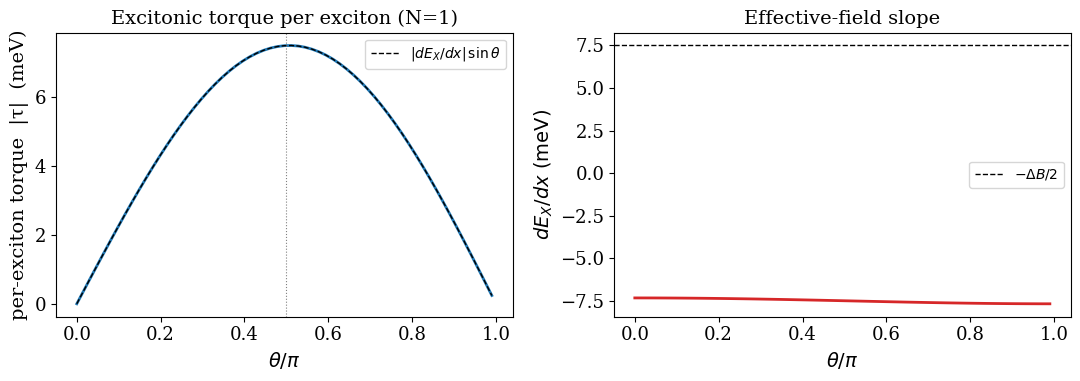

In [5]:
fig, ax = subplots(1, 2, figsize=(11.0, 4.0))
ax[1].plot(θs./π, 1e3 .* τmag, "-", lw=2, color="C0")
ax[1].plot(θs./π, 1e3 .* abs.(slope) .* sin.(θs), "k--", lw=1,
           label=L"|dE_X/dx|\,\sin\theta")
ax[1].set_xlabel(L"\theta/\pi"); ax[1].set_ylabel("per-exciton torque  |τ|  (meV)")
ax[1].set_title("Excitonic torque per exciton (N=1)"); ax[1].legend()
ax[1].axvline(0.5, color="gray", ls=":", lw=0.8)

ax[2].plot(θs./π, 1e3 .* slope, "-", lw=2, color="C3")
ax[2].axhline(1e3*ΔB/2, color="k", ls="--", lw=1, label=L"-\Delta B/2")
ax[2].set_xlabel(L"\theta/\pi"); ax[2].set_ylabel(L"dE_X/dx\ \mathrm{(meV)}")
ax[2].set_title("Effective-field slope"); ax[2].legend()
tight_layout()

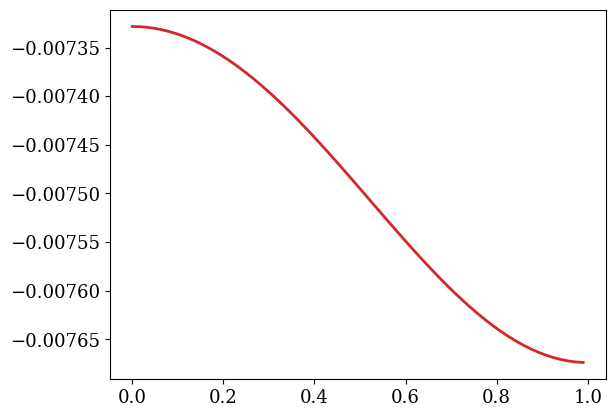

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f81c6532f30>

In [6]:
plt.plot(θs./π,  slope, "-", lw=2, color="C3")

## Cross-check: Hellmann–Feynman (reusing the full sector machinery)

The closed-form $dE_X/dx$ must equal the mode-projected vertex $Z\langle X|\Pi_x|X\rangle$ — the
$k$-summed retarded bubble of `ExcitonSpinSusceptibility`. This confirms the **retarded
coefficient** of the torque; the occupation $N$ (the lesser $D^<$) multiplies it.

In [7]:
σ_0 = ComplexF64[1 0; 0 1]; σ_x = ComplexF64[0 1; 1 0]
ϵk(k, γ) = -2γ * cos(k)
H_valence(k, θ)    = (Jv=Jpd_v*cos(θ/2); -(ϵk(k,γ_v)+2γ_v+Jv)*σ_0 + Jv*σ_x)
H_conduction(k, θ) = (c=cos(θ/2); Jc=Jpd_c*c;
                      (ϵk(k,γ_c)+2γ_c+Δ_0+(Jpd_c+Jpd_v)*(1-c)+Jc)*σ_0 - Jc*σ_x)
dHv_dc = -Jpd_v*σ_0 + Jpd_v*σ_x
dHc_dc = -Jpd_v*σ_0 - Jpd_c*σ_x
fermi(E) = 1/(exp(clamp((E-μchem)/T,-60,60))+1)
Γ_sector = [σ_0/√2, σ_x/√2]
V_s = Diagonal(ComplexF64[-V_intra, -V_inter]); Vinv_s = Matrix(inv(V_s))

function sector_data(θ; ks=ks)
    nt = 4*length(ks)
    ΔE=zeros(nt); dΔE=zeros(nt); occ=zeros(nt); w=zeros(ComplexF64,2,2,nt); t=0
    for k in ks
        Fv=eigen(Hermitian(H_valence(k,θ))); Fc=eigen(Hermitian(H_conduction(k,θ)))
        m=[Fc.vectors'*Γ*Fv.vectors for Γ in Γ_sector]
        for a in 1:2, b in 1:2
            t+=1
            ΔE[t]=Fc.values[a]-Fv.values[b]
            dΔE[t]=real(Fc.vectors[:,a]'*dHc_dc*Fc.vectors[:,a]) -
                   real(Fv.vectors[:,b]'*dHv_dc*Fv.vectors[:,b])
            occ[t]=fermi(Fv.values[b])-fermi(Fc.values[a])
            for α in 1:2, β in 1:2; w[α,β,t]=m[α][a,b]*conj(m[β][a,b]); end
        end
    end
    return (; ΔE,dΔE,occ,w,L=length(ks),c=cos(θ/2))
end
Πs(d,Ω;η=0.0)  = (P=zeros(ComplexF64,2,2); for t in eachindex(d.ΔE); @views P.+=(d.occ[t]/(Ω+1im*η-d.ΔE[t])).*d.w[:,:,t]; end; P./d.L)
∂Πs(d,Ω)       = (P=zeros(ComplexF64,2,2); for t in eachindex(d.ΔE); @views P.+=(-d.occ[t]/(Ω-d.ΔE[t])^2).*d.w[:,:,t]; end; P./d.L)
Πc(d,Ω;η=0.0)  = (P=zeros(ComplexF64,2,2); for t in eachindex(d.ΔE); @views P.+=(d.occ[t]*d.dΔE[t]/(Ω+1im*η-d.ΔE[t])^2).*d.w[:,:,t]; end; P./d.L)
Πx(d,Ω;η=0.0)  = Πc(d,Ω;η=η) ./ (4*d.c)

function exciton_mode(θ)
    d=sector_data(θ); cont_min=minimum(d.ΔE)
    λmax(Ω)=maximum(real(eigvals(Hermitian(Vinv_s-Πs(d,Ω)))))
    lo,hi=0.0,cont_min-1e-9
    for _ in 1:100; mid=(lo+hi)/2; (λmax(mid)<0) ? (lo=mid) : (hi=mid); end
    EX=(lo+hi)/2
    F=eigen(Hermitian(Vinv_s-Πs(d,EX))); X=F.vectors[:,argmax(real(F.values))]
    X=X.*exp(-1im*angle(X[1])); Z=-1/real(X'*∂Πs(d,EX)*X)
    return (; EX,X,Z,data=d)
end

println("Hellmann–Feynman:  Z⟨X|Π_x|X⟩   vs   closed-form dE_X/dx")
for θv in (0.0, π/4, π/2, 3π/4, 0.95π)
    m = exciton_mode(θv)
    gHF = m.Z * real(m.X' * Πx(m.data, m.EX) * m.X)
    an  = EX_and_slope(θv).dEXdx
    @printf("  θ/π=%.2f:  HF=%.4f meV   closed=%.4f meV   |diff|=%.1e\n",
            θv/π, 1e3*gHF, 1e3*an, abs(gHF-an))
end

Hellmann–Feynman:  Z⟨X|Π_x|X⟩   vs   closed-form dE_X/dx
  θ/π=0.00:  HF=-7.3283 meV   closed=-7.3283 meV   |diff|=1.7e-18
  θ/π=0.25:  HF=-7.3760 meV   closed=-7.3760 meV   |diff|=8.7e-18
  θ/π=0.50:  HF=-7.4952 meV   closed=-7.4952 meV   |diff|=4.9e-17
  θ/π=0.75:  HF=-7.6203 meV   closed=-7.6203 meV   |diff|=3.5e-17
  θ/π=0.95:  HF=-7.6717 meV   closed=-7.6717 meV   |diff|=1.9e-16


## Reading and next step

* The exciton sector gives an **internal torque** between the layers,
  $\tau=-(dE_X/dx)\,(M_1\times M_2)$, of magnitude $|dE_X/dx|\sin\theta\approx(\Delta B/2)\sin\theta$
  — **per exciton $\approx 7.5$ meV at $\theta=\pi/2$**, vanishing at FM/AFM, along the axis
  normal to the two moments ($\hat y$ here).
* The torque itself is a **mean value → the lesser $D^<$** in the trace, hence $\propto N$: an
  empty exciton exerts no mean force. The single $D$ (no $R$–$<$ loop) lets it factorize as
  $T=N\times(dE_X/dx)\times(M_1\times M_2)$; plotted here at $N=1$. Only the coefficient
  $dE_X/dx$ is retarded (HF pole shift).

**Next (model improvement):** promote $N$ to a microscopic excited-state population —
two-channel HS (charge $\to W$ screening, exciton $\to \Phi$), $\Pi$ built with the excited
$G$ (phase-space filling), and the genuine $N$-dependence of $E_X$. The **damping** (second
variation) is where the Keldysh loop with $D^<\!\propto\!N$ becomes unavoidable.